In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("EdTech_Student_Learning_and_Placement_Gigantic_Dataset - EdTech_Student_Learning_and_Placement_Gigantic_Dataset.csv.csv")

In [3]:
# chack data

In [4]:
df.head()

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
0,1000000,2022-05-29,West,Mumbai,Python,Offline,144770.33,40.0,Ongoing,Not Placed
1,1000001,2022-01-29,NaN,Chennai,Web Development,Hybrid,174792.23,52.0,NaN,Not Placed
2,1000002,2021-01-22,South,Kolkata,Web Development,Online,92417.81,79.0,Completed,Placed
3,1000003,2022-12-15,North,Pune,Cyber Security,Online,105916.82,89.0,Dropped,Not Placed
4,1000004,2022-06-07,East,Hyderabad,Python,Offline,18927.99,68.0,Completed,Not Eligible


In [5]:
df.shape

(76000, 10)

In [6]:
df.sample(10)

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
28248,1028248,2020-12-07,NaN,Mumbai,AI/ML,Hybrid,243823.69,50.0,Ongoing,Not Eligible
47276,1047276,2021-10-08,NaN,Bengaluru,Data Science,Offline,98705.81,99.0,Ongoing,Not Placed
20330,1020330,2021-10-08,East,Chennai,Cyber Security,Online,78321.63,59.0,Ongoing,Not Eligible
73212,1013655,2020-12-03,North,NaN,AI/ML,Online,132384.04,40.0,Ongoing,Not Placed
27261,1027261,2020-11-24,South,NaN,Python,Online,80188.07,63.0,Dropped,Placed
72861,1059131,2023-05-04,West,Chennai,AI/ML,Online,143749.61,49.0,Completed,Placed
70394,1070394,2022-08-28,NaN,Ahmedabad,Python,Offline,97385.67,78.0,Ongoing,NaN
75997,1069831,2022-03-16,North,Delhi,Web Development,Online,143528.38,83.0,Dropped,Placed
29515,1029515,2021-04-20,South,Bengaluru,NaN,Hybrid,127366.21,61.0,NaN,Not Eligible
57300,1057300,2023-07-08,Central,Hyderabad,Cyber Security,Hybrid,92484.58,48.0,Ongoing,Not Placed


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          76000 non-null  int64  
 1   Enrollment_Date     76000 non-null  object 
 2   Region              57388 non-null  object 
 3   City                67430 non-null  object 
 4   Course_Name         68481 non-null  object 
 5   Learning_Mode       76000 non-null  object 
 6   Fees_Paid           76000 non-null  float64
 7   Attendance_Percent  74756 non-null  float64
 8   Course_Status       68492 non-null  object 
 9   Placement_Status    68473 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 5.8+ MB


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72000 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          72000 non-null  int64  
 1   Enrollment_Date     72000 non-null  object 
 2   Region              54346 non-null  object 
 3   City                63833 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       72000 non-null  object 
 6   Fees_Paid           72000 non-null  float64
 7   Attendance_Percent  70817 non-null  float64
 8   Course_Status       64870 non-null  object 
 9   Placement_Status    64875 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [10]:
df["Region"].unique()

array(['West', nan, 'South', 'North', 'East', 'Central'], dtype=object)

In [11]:
df["Region"]=df["Region"].fillna("Other")

In [12]:
df["Region"].unique()

array(['West', 'Other', 'South', 'North', 'East', 'Central'], dtype=object)

In [13]:
df["City"].unique()

array(['Mumbai', 'Chennai', 'Kolkata', 'Pune', 'Hyderabad', 'Ahmedabad',
       'Bengaluru', nan, 'Delhi'], dtype=object)

In [14]:
df["City"]=df["City"].fillna("Other")

In [15]:
df["Course_Name"].unique()

array(['Python', 'Web Development', 'Cyber Security', 'AI/ML',
       'Data Science', nan, 'Cloud Computing'], dtype=object)

In [16]:
df["Course_Name"]=df["Course_Name"].dropna()

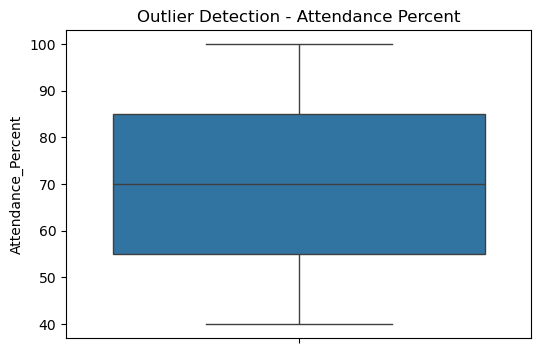

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Attendance_Percent'])

plt.title("Outlier Detection - Attendance Percent")
plt.show()

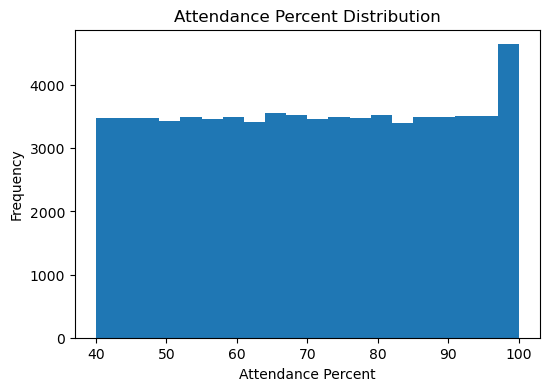

In [18]:
plt.figure(figsize=(6,4))
plt.hist(df['Attendance_Percent'], bins=20)

plt.title("Attendance Percent Distribution")
plt.xlabel("Attendance Percent")
plt.ylabel("Frequency")

plt.show()

In [19]:
df["Attendance_Percent"]=df["Attendance_Percent"].fillna(np.mean(df["Attendance_Percent"]))

In [20]:
df["Course_Status"].value_counts()

Course_Status
Ongoing      32681
Completed    21317
Dropped      10872
Name: count, dtype: int64

In [21]:
df.loc[
    (df['Course_Status'].isna()) & (df['Placement_Status'] == 'Placed'),
    'Course_Status'
] = 'Completed'

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72000 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          72000 non-null  int64  
 1   Enrollment_Date     72000 non-null  object 
 2   Region              72000 non-null  object 
 3   City                72000 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       72000 non-null  object 
 6   Fees_Paid           72000 non-null  float64
 7   Attendance_Percent  72000 non-null  float64
 8   Course_Status       66990 non-null  object 
 9   Placement_Status    64875 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [23]:
df.loc[
    (df['Course_Status'].isna()) & (df['Placement_Status'] == 'Not Eligible'),
    'Course_Status'
] = 'Dropped'

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72000 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          72000 non-null  int64  
 1   Enrollment_Date     72000 non-null  object 
 2   Region              72000 non-null  object 
 3   City                72000 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       72000 non-null  object 
 6   Fees_Paid           72000 non-null  float64
 7   Attendance_Percent  72000 non-null  float64
 8   Course_Status       68418 non-null  object 
 9   Placement_Status    64875 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [25]:

df.loc[
    (df['Course_Status'].isna()) & (df['Placement_Status'] == 'Not Placed'),
    'Course_Status'
] = 'Ongoing'

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72000 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          72000 non-null  int64  
 1   Enrollment_Date     72000 non-null  object 
 2   Region              72000 non-null  object 
 3   City                72000 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       72000 non-null  object 
 6   Fees_Paid           72000 non-null  float64
 7   Attendance_Percent  72000 non-null  float64
 8   Course_Status       71302 non-null  object 
 9   Placement_Status    64875 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [27]:
df[df["Course_Status"].isna()]

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
44,1000044,2021-03-30,West,Other,NaN,Online,233726.60,53.0,NaN,NaN
195,1000195,2022-09-16,Other,Kolkata,AI/ML,Hybrid,243964.85,88.0,NaN,NaN
217,1000217,2020-12-01,East,Ahmedabad,Python,Online,41353.12,48.0,NaN,NaN
620,1000620,2022-03-27,East,Hyderabad,Python,Online,169231.35,98.0,NaN,NaN
758,1000758,2023-02-21,Other,Kolkata,Cyber Security,Online,173407.68,61.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
71075,1071075,2023-06-26,North,Kolkata,Python,Online,175261.46,50.0,NaN,NaN
71134,1071134,2021-07-13,South,Other,Data Science,Online,205394.70,59.0,NaN,NaN
71154,1071154,2021-09-16,East,Kolkata,Python,Offline,40674.23,40.0,NaN,NaN
71821,1071821,2020-12-01,West,Pune,Python,Online,15797.89,91.0,NaN,NaN


In [28]:
df = df.dropna(subset=['Course_Name', 'Placement_Status'], how='all')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          71358 non-null  int64  
 1   Enrollment_Date     71358 non-null  object 
 2   Region              71358 non-null  object 
 3   City                71358 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       71358 non-null  object 
 6   Fees_Paid           71358 non-null  float64
 7   Attendance_Percent  71358 non-null  float64
 8   Course_Status       70724 non-null  object 
 9   Placement_Status    64875 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [30]:
df["Course_Status"].unique()

array(['Ongoing', 'Completed', 'Dropped', nan], dtype=object)

In [31]:
df["Placement_Status"].unique()

array(['Not Placed', 'Placed', 'Not Eligible', nan], dtype=object)

In [32]:
df.loc[
    (df['Course_Name'].notna()) & (df['Course_Status'].isna()),
    'Course_Status'
] = 'Ongoing'

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          71358 non-null  int64  
 1   Enrollment_Date     71358 non-null  object 
 2   Region              71358 non-null  object 
 3   City                71358 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       71358 non-null  object 
 6   Fees_Paid           71358 non-null  float64
 7   Attendance_Percent  71358 non-null  float64
 8   Course_Status       71358 non-null  object 
 9   Placement_Status    64875 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [34]:
df.loc[
    (df['Placement_Status'].isna()) & (df['Course_Status'] == 'Ongoing'),
    'Placement_Status'
] = 'Not Placed'

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          71358 non-null  int64  
 1   Enrollment_Date     71358 non-null  object 
 2   Region              71358 non-null  object 
 3   City                71358 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       71358 non-null  object 
 6   Fees_Paid           71358 non-null  float64
 7   Attendance_Percent  71358 non-null  float64
 8   Course_Status       71358 non-null  object 
 9   Placement_Status    68432 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [36]:
result = df.groupby(['Course_Status','Placement_Status']).size()

print(result)

Course_Status  Placement_Status
Completed      Not Eligible         4260
               Not Placed           8559
               Placed               8488
Dropped        Not Eligible         3603
               Not Placed           4375
               Placed               3255
Ongoing        Not Eligible         6683
               Not Placed          19378
               Placed               9831
dtype: int64


In [37]:
df.loc[
    (df['Placement_Status'].isna()) & (df['Course_Status'] == 'Completed'),
    'Placement_Status'
] = 'Placed'

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          71358 non-null  int64  
 1   Enrollment_Date     71358 non-null  object 
 2   Region              71358 non-null  object 
 3   City                71358 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       71358 non-null  object 
 6   Fees_Paid           71358 non-null  float64
 7   Attendance_Percent  71358 non-null  float64
 8   Course_Status       71358 non-null  object 
 9   Placement_Status    70369 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [39]:
df[df["Placement_Status"].isna()]

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
146,1000146,2020-06-23,Other,Hyderabad,Cyber Security,Hybrid,163784.22,73.0,Dropped,NaN
454,1000454,2022-05-08,South,Kolkata,Data Science,Online,239787.30,76.0,Dropped,NaN
568,1000568,2022-05-08,North,Hyderabad,Cyber Security,Online,221779.37,53.0,Dropped,NaN
602,1000602,2021-08-06,Other,Ahmedabad,Cyber Security,Online,142740.87,87.0,Dropped,NaN
713,1000713,2022-12-20,Central,Hyderabad,Cyber Security,Offline,232835.22,94.0,Dropped,NaN
...,...,...,...,...,...,...,...,...,...,...
71682,1071682,2023-02-10,West,Other,Web Development,Online,129233.71,69.0,Dropped,NaN
71699,1071699,2023-07-16,East,Delhi,Python,Online,169595.33,57.0,Dropped,NaN
71770,1071770,2022-08-29,Central,Kolkata,AI/ML,Offline,73065.73,86.0,Dropped,NaN
71905,1071905,2022-05-02,West,Hyderabad,Cyber Security,Hybrid,36497.51,81.0,Dropped,NaN


In [40]:
df.loc[
    (df['Placement_Status'].isna()) & (df['Course_Status'] == 'Dropped'),
    'Placement_Status'
] = 'Not Placed'

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          71358 non-null  int64  
 1   Enrollment_Date     71358 non-null  object 
 2   Region              71358 non-null  object 
 3   City                71358 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       71358 non-null  object 
 6   Fees_Paid           71358 non-null  float64
 7   Attendance_Percent  71358 non-null  float64
 8   Course_Status       71358 non-null  object 
 9   Placement_Status    71358 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [42]:
df[df["Course_Name"].isna()]

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
19,1000019,2022-04-28,Other,Hyderabad,NaN,Online,217733.41,70.040696,Ongoing,Not Placed
24,1000024,2020-10-11,Other,Delhi,NaN,Online,181504.10,83.000000,Completed,Not Placed
26,1000026,2021-10-25,East,Pune,NaN,Offline,153059.60,48.000000,Ongoing,Placed
30,1000030,2022-08-15,South,Bengaluru,NaN,Online,217974.71,70.040696,Completed,Not Placed
62,1000062,2022-04-28,North,Bengaluru,NaN,Online,30747.97,61.000000,Completed,Not Eligible
...,...,...,...,...,...,...,...,...,...,...
71965,1071965,2021-11-02,Other,Bengaluru,NaN,Offline,218043.09,43.000000,Completed,Placed
71967,1071967,2021-11-17,South,Pune,NaN,Online,210230.76,78.000000,Ongoing,Not Eligible
71992,1071992,2021-05-01,Other,Delhi,NaN,Hybrid,220598.59,80.000000,Completed,Placed
71997,1071997,2022-08-05,West,Other,NaN,Online,212770.78,40.000000,Ongoing,Placed


In [43]:
# df.dropna(subset=["Course_Name"], inplace=True)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          71358 non-null  int64  
 1   Enrollment_Date     71358 non-null  object 
 2   Region              71358 non-null  object 
 3   City                71358 non-null  object 
 4   Course_Name         64845 non-null  object 
 5   Learning_Mode       71358 non-null  object 
 6   Fees_Paid           71358 non-null  float64
 7   Attendance_Percent  71358 non-null  float64
 8   Course_Status       71358 non-null  object 
 9   Placement_Status    71358 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 6.0+ MB


In [45]:
# df["Course_Name"].dropna()

In [46]:
df[df[["Student_ID","Course_Name","Learning_Mode"]].duplicated()]

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status


In [47]:
df["Student_ID"].duplicated().sum()

0

In [48]:
df["Enrollment_Date"] = pd.to_datetime(df["Enrollment_Date"])

In [49]:
df.to_csv("clean_EdTech_Student_Learning_and_Placement_Gigantic_Dataset.csv")

In [50]:
df["Course_Status"].unique()

array(['Ongoing', 'Completed', 'Dropped'], dtype=object)

In [51]:
df["Placement_Status"].unique()

array(['Not Placed', 'Placed', 'Not Eligible'], dtype=object)

In [52]:
placement_rate = (
    df[df["Course_Status"]=="Completed"]["Placement_Status"]
    .value_counts(normalize=True)*100
)

In [53]:
placement_rate

Placement_Status
Placed          44.850284
Not Placed      36.822406
Not Eligible    18.327310
Name: proportion, dtype: float64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Student_ID          71358 non-null  int64         
 1   Enrollment_Date     71358 non-null  datetime64[ns]
 2   Region              71358 non-null  object        
 3   City                71358 non-null  object        
 4   Course_Name         64845 non-null  object        
 5   Learning_Mode       71358 non-null  object        
 6   Fees_Paid           71358 non-null  float64       
 7   Attendance_Percent  71358 non-null  float64       
 8   Course_Status       71358 non-null  object        
 9   Placement_Status    71358 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 6.0+ MB


In [55]:
df.to_csv("clean_EdTech_Student_Learning_and_Placement_Gigantic_Dataset.csv",index=False)

In [57]:

mode_course = df.groupby("Learning_Mode")["Course_Name"].agg(lambda x: x.mode()[0])

# fill missing values
def fill_course(row):
    if pd.isna(row["Course_Name"]):
        return mode_course[row["Learning_Mode"]]
    return row["Course_Name"]

df["Course_Name"] = df.apply(fill_course, axis=1)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71358 entries, 0 to 71999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Student_ID          71358 non-null  int64         
 1   Enrollment_Date     71358 non-null  datetime64[ns]
 2   Region              71358 non-null  object        
 3   City                71358 non-null  object        
 4   Course_Name         71358 non-null  object        
 5   Learning_Mode       71358 non-null  object        
 6   Fees_Paid           71358 non-null  float64       
 7   Attendance_Percent  71358 non-null  float64       
 8   Course_Status       71358 non-null  object        
 9   Placement_Status    71358 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 6.0+ MB


In [59]:
df.to_csv("clean_EdTech_Student_Learning_and_Placement_Gigantic_Dataset.csv",index=False)